# Task 2: Image Data Collection and Processing
**Formative 2 -- Multimodal Data Preprocessing Assignment**

This notebook is fully self-contained: given the team's zip file of photos, it extracts, validates, displays, augments, and extracts features from every member's images, ending with `image_features.csv`. Every step below can be run top-to-bottom in a fresh Colab session with nothing but the zip file uploaded.

**Requirements covered:**
- Submit >= 3 facial images per member: neutral, smiling, surprised
- Load and display sample pictures of each member
- Apply augmentations per image (rotation, flipping, grayscale)
- Extract and save image features (histograms + HOG) into `image_features.csv`

In [1]:
import os
import glob
import hashlib
import zipfile
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from skimage.feature import hog

RAW_DIR = 'data/raw'
AUG_DIR = 'data/augmented'
FEATURES_DIR = 'data/features'

for d in [RAW_DIR, AUG_DIR, FEATURES_DIR]:
    os.makedirs(d, exist_ok=True)

VALID_EXPRESSIONS = {'neutral', 'smiling', 'surprised'}

## 1. Extract images from the team zip
Expected zip structure: **one folder per member, containing 3 files named for the expression** -- e.g. `formative2/rachel/neutral.jpeg`, `formative2/rachel/smiling.jpeg`, `formative2/rachel/surprised.jpeg`. This is flattened into `data/raw/<member>_<expression>.jpg`, one consistent naming convention regardless of how deep the folder nesting is or what the zip's top-level folder is called.

In [3]:
ZIP_PATH = '/content/formative2.zip'

def extract_zip(zip_path, dest_dir):
    extracted = 0
    with zipfile.ZipFile(zip_path, 'r') as zf:
        for info in zf.infolist():
            name = info.filename
            fname = os.path.basename(name)
            if not fname or fname.startswith('.') or '__MACOSX' in name:
                continue
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            parts = [p for p in name.split('/') if p]
            if len(parts) < 2:
                print(f'Skipping {name} -- not inside a member subfolder')
                continue
            member = parts[-2]
            expression = os.path.splitext(fname)[0].strip().lower()
            if expression not in VALID_EXPRESSIONS:
                print(f'Skipping {name} -- "{expression}" is not a recognized expression '
                      f'(expected one of {VALID_EXPRESSIONS})')
                continue
            dst_path = os.path.join(dest_dir, f'{member}_{expression}.jpg')
            with zf.open(info) as src, open(dst_path, 'wb') as dst:
                dst.write(src.read())
            extracted += 1
    return extracted

if os.path.exists(ZIP_PATH):
    n = extract_zip(ZIP_PATH, RAW_DIR)
    print(f'Extracted {n} images from {ZIP_PATH} into {RAW_DIR}/')
elif os.path.exists(RAW_DIR) and len(os.listdir(RAW_DIR)) > 0:
    print(f'No zip found at {ZIP_PATH} -- using existing files already in {RAW_DIR}/')
else:
    raise FileNotFoundError(
        f'No zip found at {ZIP_PATH} AND {RAW_DIR}/ is empty. '
        f'Upload your team zip to Colab and/or fix ZIP_PATH above before continuing.'
    )

raw_files = sorted(os.listdir(RAW_DIR))
print(f'\n{len(raw_files)} files in {RAW_DIR}/:')
print(raw_files)
assert len(raw_files) > 0, f'{RAW_DIR}/ is empty -- fix ZIP_PATH above before continuing.'

Extracted 12 images from /content/formative2.zip into data/raw/

12 files in data/raw/:
['Ayiii_neutral.jpg', 'Ayiii_smiling.jpg', 'Ayiii_surprised.jpg', 'larissa_neutral.jpg', 'larissa_smiling.jpg', 'larissa_surprised.jpg', 'meme_neutral.jpg', 'meme_smiling.jpg', 'meme_surprised.jpg', 'rachel_neutral.jpg', 'rachel_smiling.jpg', 'rachel_surprised.jpg']


## 2. Build the manifest and validate submissions
Two checks, not just one: every member has all 3 expressions, **and** no two of a member's photos are accidental byte-for-byte duplicates (a real mistake that's invisible by eye but not by file hash -- e.g. someone resubmitting the same photo under two different expression names by accident).

In [4]:
def parse_filename(fname):
    base = os.path.splitext(os.path.basename(fname))[0]
    member, _, expression = base.rpartition('_')
    return member, expression

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

records = []
for path in sorted(glob.glob(os.path.join(RAW_DIR, '*'))):
    member, expression = parse_filename(path)
    records.append({'member': member, 'expression': expression, 'path': path,
                     'hash': file_hash(path)})

manifest = pd.DataFrame(records)

# --- check 1: every member has all 3 expressions ---
counts = manifest.groupby('member')['expression'].nunique()
incomplete = counts[counts < 3]
if len(incomplete):
    print('WARNING - these members are missing at least one expression:')
    print(incomplete)
else:
    print(f'All {len(counts)} members have all 3 expressions ({"neutral"}, {"smiling"}, {"surprised"}).')

# --- check 2: no byte-identical duplicate photos within a member ---
dupe_found = False
for member, group in manifest.groupby('member'):
    dupes = group[group.duplicated('hash', keep=False)]
    if len(dupes):
        dupe_found = True
        print(f"WARNING - {member}: {dupes['expression'].tolist()} are byte-identical files "
              f"-- these are not really 3 distinct expressions and should be re-submitted.")
if not dupe_found:
    print('No duplicate photos detected.')

manifest[['member', 'expression', 'path']]

All 4 members have all 3 expressions (neutral, smiling, surprised).
No duplicate photos detected.


,member,expression,path
0,Ayiii,neutral,data/raw/Ayiii_neutral.jpg
1,Ayiii,smiling,data/raw/Ayiii_smiling.jpg
2,Ayiii,surprised,data/raw/Ayiii_surprised.jpg
3,larissa,neutral,data/raw/larissa_neutral.jpg
4,larissa,smiling,data/raw/larissa_smiling.jpg
5,larissa,surprised,data/raw/larissa_surprised.jpg
6,meme,neutral,data/raw/meme_neutral.jpg
7,meme,smiling,data/raw/meme_smiling.jpg
8,meme,surprised,data/raw/meme_surprised.jpg
9,rachel,neutral,data/raw/rachel_neutral.jpg


## 3. Load and display sample pictures of each member

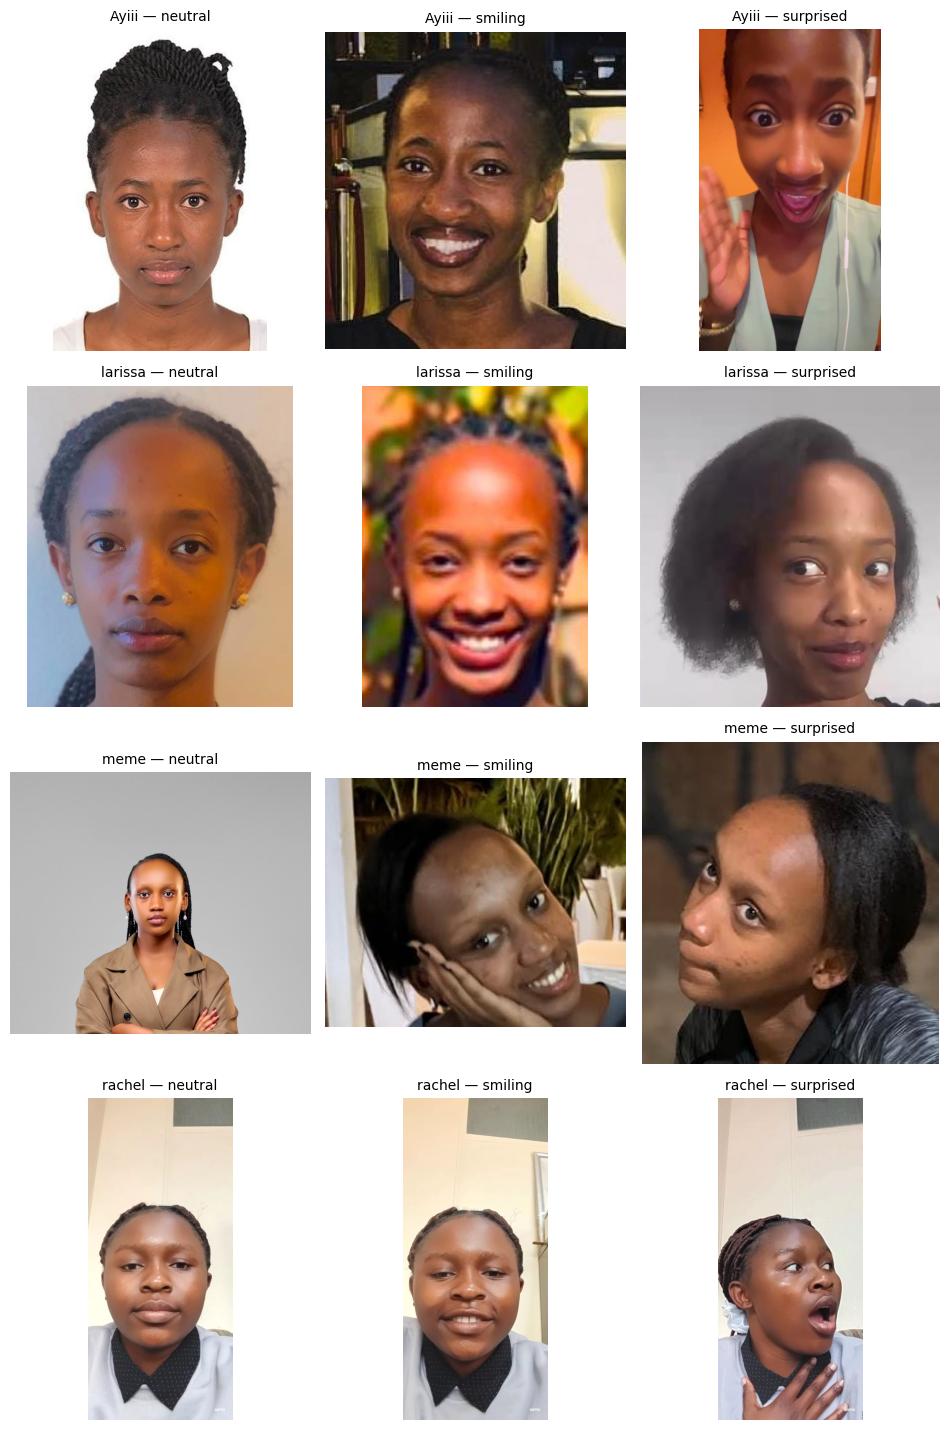

In [5]:
members = sorted(manifest['member'].unique())
expr_order = ['neutral', 'smiling', 'surprised']

fig, axes = plt.subplots(len(members), len(expr_order),
                         figsize=(3.2 * len(expr_order), 3.6 * len(members)))
if len(members) == 1:
    axes = axes.reshape(1, -1)

for i, member in enumerate(members):
    for j, expr in enumerate(expr_order):
        ax = axes[i, j]
        row = manifest[(manifest['member'] == member) & (manifest['expression'] == expr)]
        if len(row):
            img = Image.open(row.iloc[0]['path'])
            ax.imshow(img)
            ax.set_title(f'{member} — {expr}', fontsize=10)
        else:
            ax.text(0.5, 0.5, 'not submitted yet', ha='center', va='center',
                    fontsize=9, color='gray')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Augmentations
3 augmentations per image (exceeds the >= 2 required), saved to `data/augmented/` as `<member>_<expression>_<augmentation>.jpg`:
- **Rotation** (25 degrees)
- **Horizontal flip**
- **Grayscale conversion**

In [6]:
def augment_and_save(path, member, expression):
    img = Image.open(path).convert('RGB')
    outputs = {
        'rotated': img.rotate(25, expand=True, fillcolor=(255, 255, 255)),
        'flipped': ImageOps.mirror(img),
        'grayscale': ImageOps.grayscale(img).convert('RGB'),
    }
    saved = {}
    for aug_name, aug_img in outputs.items():
        out_path = os.path.join(AUG_DIR, f'{member}_{expression}_{aug_name}.jpg')
        aug_img.save(out_path)
        saved[aug_name] = out_path
    return saved

augmented_rows = []
for _, row in manifest.iterrows():
    saved = augment_and_save(row['path'], row['member'], row['expression'])
    for aug_name, aug_path in saved.items():
        augmented_rows.append({'member': row['member'], 'expression': row['expression'],
                               'augmentation': aug_name, 'path': aug_path})

augmented_df = pd.DataFrame(augmented_rows)
print(f'Saved {len(augmented_df)} augmented images to {AUG_DIR}/')
augmented_df.head()

Saved 36 augmented images to data/augmented/


,member,expression,augmentation,path
0,Ayiii,neutral,rotated,data/augmented/Ayiii_neutral_rotated.jpg
1,Ayiii,neutral,flipped,data/augmented/Ayiii_neutral_flipped.jpg
2,Ayiii,neutral,grayscale,data/augmented/Ayiii_neutral_grayscale.jpg
3,Ayiii,smiling,rotated,data/augmented/Ayiii_smiling_rotated.jpg
4,Ayiii,smiling,flipped,data/augmented/Ayiii_smiling_flipped.jpg


### Preview: original vs. augmentations (first image as example)

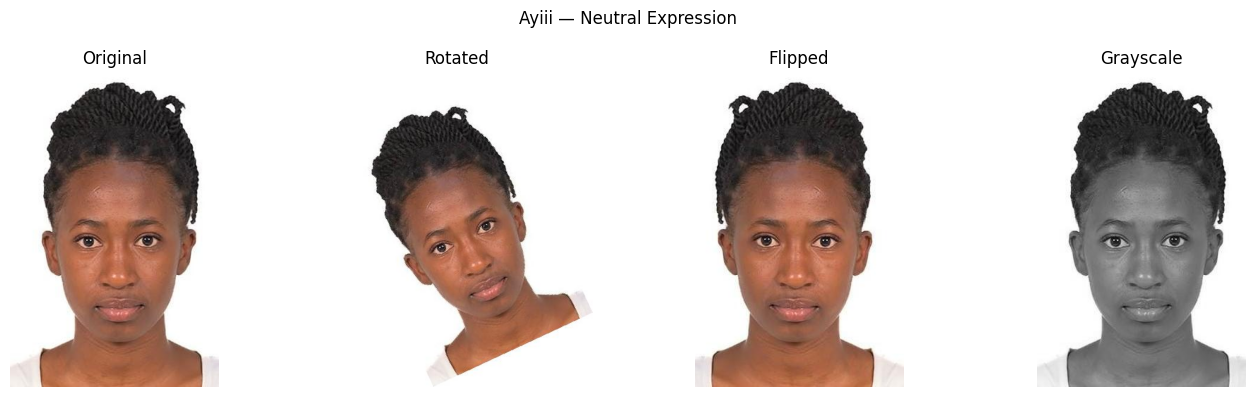

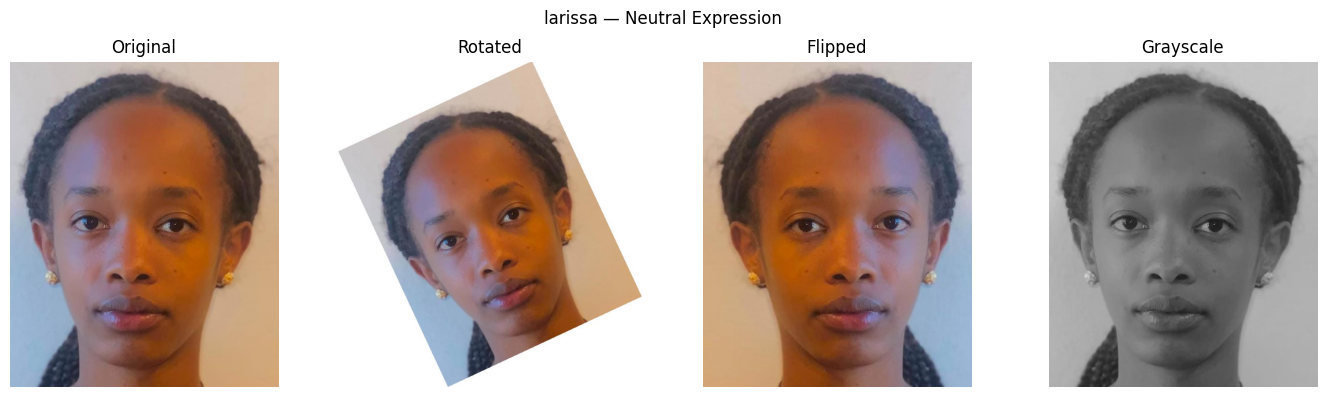

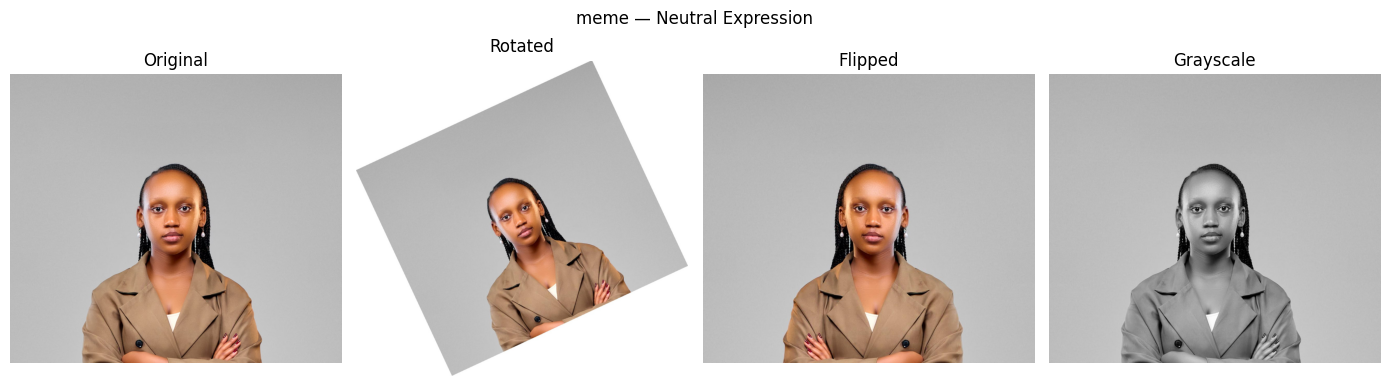

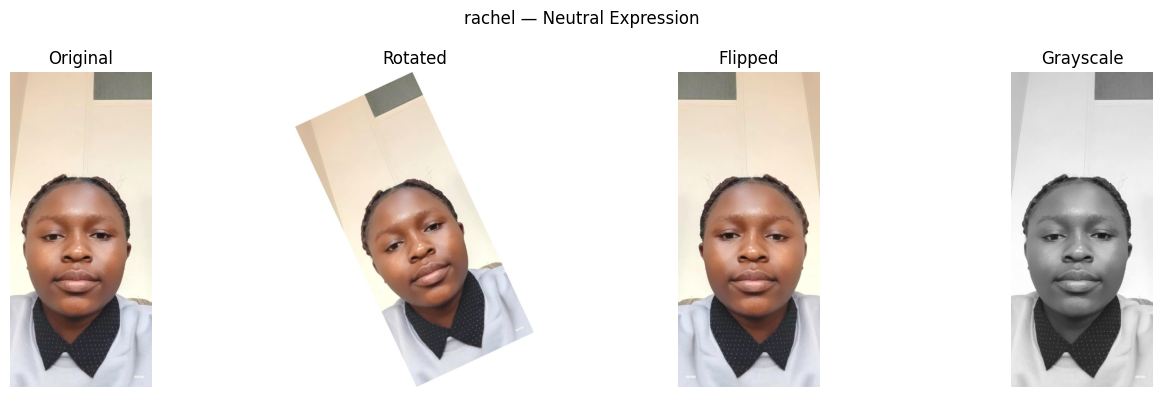

In [14]:
# Get all members
members = manifest['member'].unique()

for member in members:
    # Get the original neutral image
    example = manifest[
        (manifest['member'] == member) &
        (manifest['expression'] == 'neutral')
    ].iloc[0]

    # Get the augmented versions
    example_augs = augmented_df[
        (augmented_df['member'] == member) &
        (augmented_df['expression'] == 'neutral')
    ]

    # Create a row of 4 images
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))

    # Original image
    axes[0].imshow(Image.open(example['path']))
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Rotated, Flipped, Grayscale
    for ax, (_, row) in zip(axes[1:], example_augs.iterrows()):
        ax.imshow(Image.open(row['path']))
        ax.set_title(row['augmentation'].capitalize())
        ax.axis("off")

    plt.suptitle(f"{member} — Neutral Expression")
    plt.tight_layout()
    plt.show()

## 5. Feature extraction
For every image (original **and** every augmented version) we extract:
- **Color histogram** -- 8 bins per RGB channel (24 features), normalized so it's robust to image size.
- **Grayscale histogram** -- 16 bins (16 features), captures brightness/contrast distribution.
- **HOG (Histogram of Oriented Gradients) descriptor** -- computed on a resized 64x64 grayscale version of the image, with `orientations=9`, `pixels_per_cell=(16,16)`, `cells_per_block=(1,1)`. This gives 4x4=16 cells and therefore 16 x 9 = **144 features**, independent of the original photo resolution. HOG captures edge/gradient structure -- a classic, embedding-like descriptor of facial structure that doesn't require a pretrained deep model.

In [9]:
def extract_features(path):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    color_hist = []
    for ch in range(3):
        hist = cv2.calcHist([img_rgb], [ch], None, [8], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        color_hist.extend(hist.tolist())

    gray_hist = cv2.calcHist([gray], [0], None, [16], [0, 256])
    gray_hist = cv2.normalize(gray_hist, gray_hist).flatten().tolist()

    resized = cv2.resize(gray, (64, 64))
    hog_features = hog(resized, orientations=9, pixels_per_cell=(16, 16),
                        cells_per_block=(1, 1), feature_vector=True).tolist()

    return color_hist, gray_hist, hog_features

combined = pd.concat([
    manifest[['member', 'expression', 'path']].assign(augmentation='original'),
    augmented_df,
], ignore_index=True)

rows = []
for _, row in combined.iterrows():
    color_hist, gray_hist, hog_feats = extract_features(row['path'])
    record = {
        'member': row['member'],
        'expression': row['expression'],
        'augmentation': row['augmentation'],
        'filename': os.path.basename(row['path']),
    }
    for i, v in enumerate(color_hist):
        record[f'color_hist_{i}'] = v
    for i, v in enumerate(gray_hist):
        record[f'gray_hist_{i}'] = v
    for i, v in enumerate(hog_feats):
        record[f'hog_{i}'] = v
    rows.append(record)

features_df = pd.DataFrame(rows)
print('Feature table shape:', features_df.shape)
features_df.head()

Feature table shape: (48, 188)


,member,expression,augmentation,filename,color_hist_0,color_hist_1,color_hist_2,color_hist_3,color_hist_4,color_hist_5,...,hog_134,hog_135,hog_136,hog_137,hog_138,hog_139,hog_140,hog_141,hog_142,hog_143
0,Ayiii,neutral,original,Ayiii_neutral.jpg,0.055638,0.246742,0.061553,0.086773,0.367866,0.312384,...,0.363583,0.509138,0.114334,0.019708,0.095916,0.509138,0.275919,0.509138,0.240949,0.255905
1,Ayiii,smiling,original,Ayiii_smiling.jpg,0.499786,0.380398,0.437728,0.452351,0.300953,0.146150,...,0.425144,0.358099,0.048695,0.101924,0.035505,0.454218,0.454218,0.454218,0.180248,0.454218
2,Ayiii,surprised,original,Ayiii_surprised.jpg,0.017047,0.072172,0.238822,0.396085,0.555868,0.550470,...,0.413114,0.436745,0.339181,0.056098,0.275114,0.436745,0.148788,0.403535,0.221147,0.436745
3,larissa,neutral,original,larissa_neutral.jpg,0.001338,0.103723,0.193170,0.197018,0.699914,0.381059,...,0.385457,0.370317,0.370317,0.370317,0.150968,0.370317,0.370317,0.370317,0.370317,0.131397
4,larissa,smiling,original,larissa_smiling.jpg,0.090916,0.183354,0.396080,0.339245,0.261812,0.266342,...,0.059658,0.376334,0.376334,0.343117,0.129136,0.233305,0.320976,0.376334,0.376334,0.376334


### Save features to CSV

In [10]:
out_path = os.path.join(FEATURES_DIR, 'image_features.csv')
features_df.to_csv(out_path, index=False)
print(f'Saved {len(features_df)} rows x {features_df.shape[1]} columns to {out_path}')

Saved 48 rows x 188 columns to data/features/image_features.csv


## Summary

- **Extraction:** zip's `<member>/<expression>.jpeg` structure flattened into `data/raw/<member>_<expression>.jpg` -- one consistent naming convention.
- **Validation:** every member checked for all 3 expressions *and* for accidental byte-identical duplicate photos.
- **Display:** all images shown in a member x expression grid.
- **Augmentations:** rotation, horizontal flip, and grayscale (3, exceeding the >= 2 minimum) applied to every image, saved to `data/augmented/`.
- **Features:** color histogram (24-d) + grayscale histogram (16-d) + HOG descriptor (144-d) extracted for every original **and** augmented image, saved to `data/features/image_features.csv`.